### Plotting precipitation time series with GiC time series service

* Use Giovanni time series service to plot rainfall time series in Texas using GPM-IMERG Final
* We use the nasa-gesdisc conda environment (nasa-gesdisc.yml)

In [1]:
# earthaccess is a python library to search for and download or stream NASA Earth science data with just a few lines of code
import earthaccess
import requests
import io
import pandas
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def call_time_series(lat,lon,time_start,time_end,data):
    """
    INPUTS:
    lat - latitude
    lon - longitude
    time_start - start of time series in YYYY-MM-DDThh:mm:ss format (UTC)
    end_time - end of the time series in YYYY-MM-DDThh:mm:ss format (UTC)
    data - name of the data parameter for the time series
    
    OUTPUT:
    time series csv output string
    """
    query_parameters = {
        "data":data,
        "location":"[{},{}]".format(lat,lon),
        "time":"{}/{}".format(time_start,time_end)
    }
   
    headers = {
    'Authorization': f'Bearer {token}'
    }
    
    response=requests.get(time_series_url, params=query_parameters, headers=headers)
    return response.text

In [10]:
def parse_csv(ts):
    """
    INPUTS:
    ts - time series output of the time series service
    
    OUTPUTS:
    headers,df - the headers from the CSV as a dict and the values in a pandas dataframe
    """
    with io.StringIO(ts) as f:
        # the first 13 rows are header
        headers = {}
        try:
            for i in range(13):
                line = f.readline()
                key,value = line.split(",")
                headers[key] = value.strip()
        except ValueError as e:
            raise ValueError(
                "The returned CSV is empty.\n"
                "Please ensure that your subsetting bounds are within the extent of your dataset\n"
                "or that your .netrc file is stored and contains valid credentials."
            ) from e

        # Read the csv proper
        df = pandas.read_csv(
            f,
            header=1,
            names=("Timestamp",headers["param_name"]),
            converters={"Timestamp":pandas.Timestamp}
        )

    return headers, df

In [11]:
# Use Giovanni in the Cloud time series service API to plot IMERG precipitation

# Camp Mystic Guadalupe near Hunt, TX
hunt_coords = [-99.37, 30.01] # lon, lat 

time_start = "2025-07-01T00:00:00"
time_end = "2025-07-31T23:59:00"

# data = entryID_version_variableshortname
data = "GPM_3IMERGHH_07_precipitation"

auth = earthaccess.login()
token = earthaccess.get_edl_token()['access_token']

time_series_url = "https://api.giovanni.earthdata.nasa.gov/timeseries"

ts_hunt = call_time_series(hunt_coords[1],hunt_coords[0],time_start,time_end,data)

headers_hunt,df_hunt = parse_csv(ts_hunt)
print(df_hunt.head())

            Timestamp  \
0 2025-07-01 00:00:00   
1 2025-07-01 00:30:00   
2 2025-07-01 01:00:00   
3 2025-07-01 01:30:00   
4 2025-07-01 02:00:00   

   Multi-satellite precipitation estimate with gauge calibration - Final Run (recommended for general use)  
0                                               0.11                                                        
1                                               0.05                                                        
2                                               0.03                                                        
3                                               0.00                                                        
4                                               0.00                                                        


In [14]:
# Resample to daily and plot
df_hunt.set_index("Timestamp", inplace=True)
daily_precip = df_hunt.resample('D').mean()

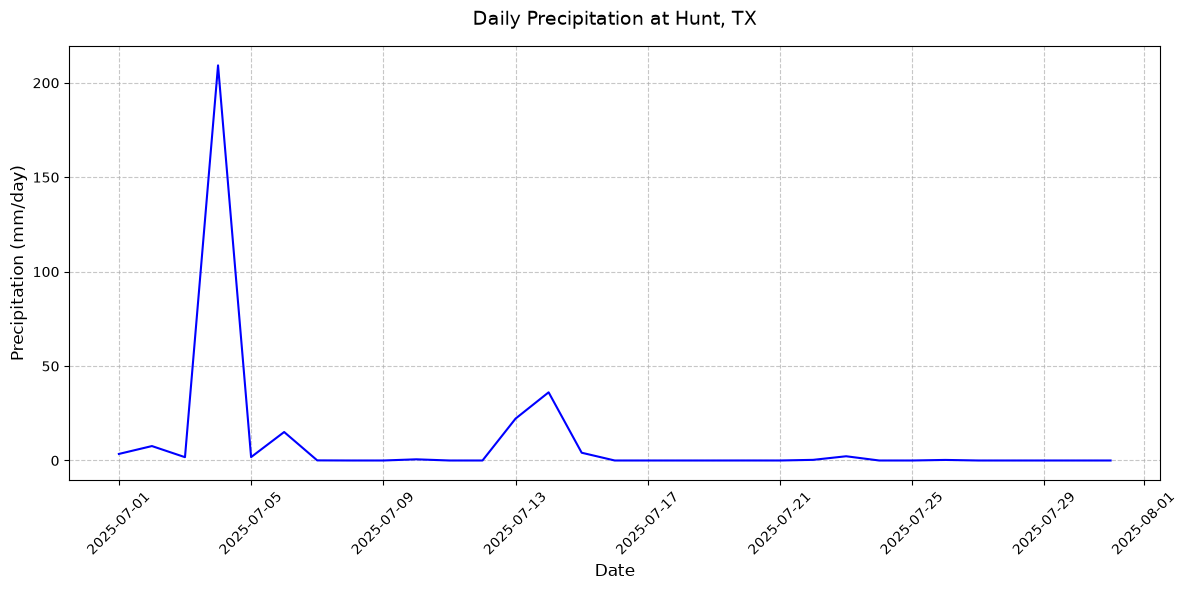

In [19]:
# Create the figure and axis
plt.figure(figsize=(12, 6))

# Plot the data (Timestamp on x-axis, Precipitation on y-axis)
#plt.plot(24*3600*daily_precip, color='blue', linewidth=1.5) # converting instantaneous rainfall to daily
plt.plot(48*daily_precip, color='blue', linewidth=1.5)

# Add titles and axis labels
plt.title('Daily Precipitation at Hunt, TX', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)

plt.ylabel('Precipitation (mm/day)', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Rotate the x-axis date labels so they don't overlap
plt.xticks(rotation=45)

# Use tight_layout so the rotated labels don't get cut off
plt.tight_layout()


In [ ]:
# Calculate average annual rainfall (as a check to make sure unit conversions are correct)
# annual_precip = df.resample("Y").mean()
# total_annual_precip = annual_precip*3600*24*365
# print(total_annual_precip)
# print(total_annual_precip.mean()) # about 1350 mm/year, which seems reasonable